**1. Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**2. Load Dataset (Data Collection)**

In [ ]:
train = pd.read_excel("IMDB_train.xlsx")
test = pd.read_excel("IMDB_test.xlsx")

In [ ]:
train.head()

,review,sentiment
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1


In [ ]:
test.head()

,review,sentiment
0,I went and saw this movie last night after bei...,1
1,Actor turned director Bill Paxton follows up h...,1
2,As a recreational golfer with some knowledge o...,1
3,"I saw this film in a sneak preview, and it is ...",1
4,Bill Paxton has taken the true story of the 19...,1


In [ ]:
train['review']

,review
0,Bromwell High is a cartoon comedy. It ran at t...
1,Homelessness (or Houselessness as George Carli...
2,Brilliant over-acting by Lesley Ann Warren. Be...
3,This is easily the most underrated film inn th...
4,This is not the typical Mel Brooks film. It wa...
...,...
24995,"Towards the end of the movie, I felt it was to..."
24996,This is the kind of movie that my enemies cont...
24997,I saw 'Descent' last night at the Stockholm Fi...
24998,Some films that you pick up for a pound turn o...


In [ ]:
test['review']

,review
0,I went and saw this movie last night after bei...
1,Actor turned director Bill Paxton follows up h...
2,As a recreational golfer with some knowledge o...
3,"I saw this film in a sneak preview, and it is ..."
4,Bill Paxton has taken the true story of the 19...
...,...
24995,I occasionally let my kids watch this garbage ...
24996,When all we have anymore is pretty much realit...
24997,The basic genre is a thriller intercut with an...
24998,Four things intrigued me as to this film - fir...


**3. Exploratary Data Analysis (EDA) - Understand the data**

In [ ]:
print("\n===== Basic Info =====")
print(train.info())


===== Basic Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     25000 non-null  object
 1   sentiment  25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB
None


In [ ]:
print("\n===== Missing Values =====")
print(train.isnull().sum())


===== Missing Values =====
review       0
sentiment    0
dtype: int64


**3.1 Class Distribution**

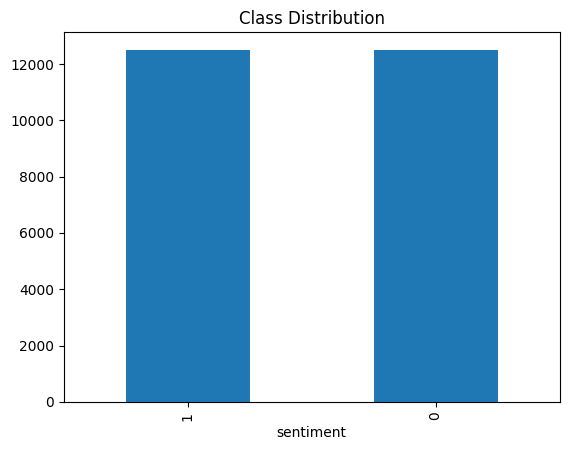

sentiment
1    0.5
0    0.5
Name: proportion, dtype: float64


In [ ]:
plt.figure()
train['sentiment'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

print(train['sentiment'].value_counts(normalize=True))

**3.2 Text Length**

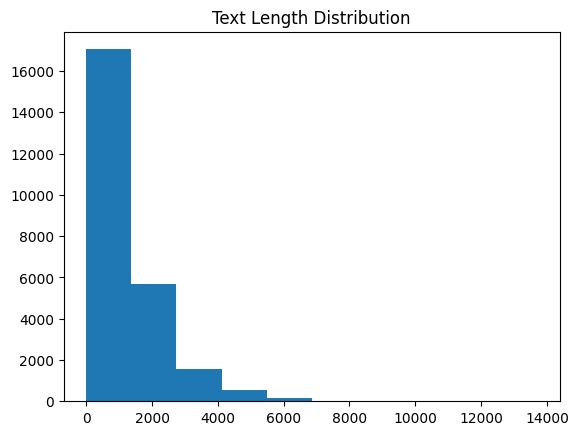

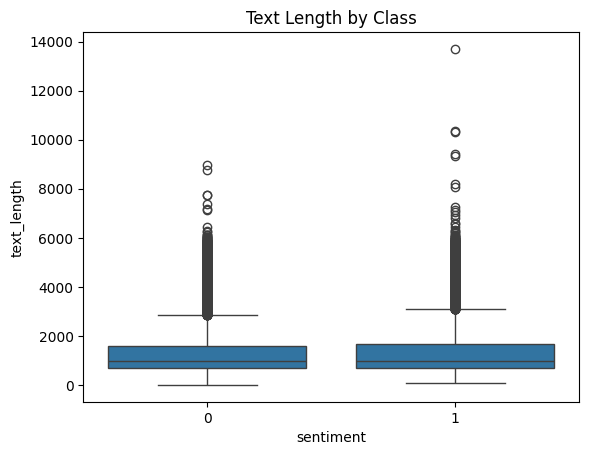

In [ ]:
train['text_length'] = train['review'].astype(str).apply(len)

plt.figure()
plt.hist(train['text_length'])
plt.title("Text Length Distribution")
plt.show()

plt.figure()
sns.boxplot(x=train['sentiment'], y=train['text_length'])
plt.title("Text Length by Class")
plt.show()

**3.3 Word Count**

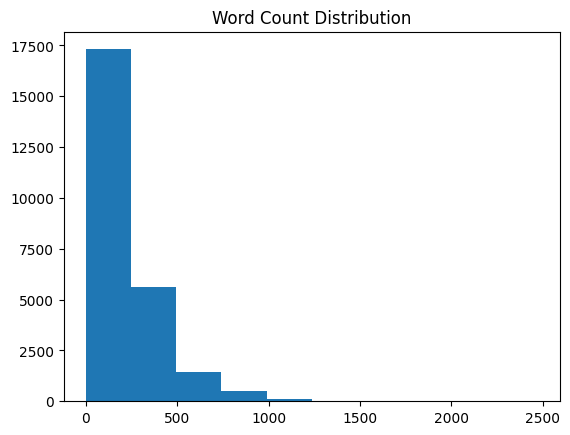

In [ ]:
train['word_count'] = train['review'].apply(lambda x: len(str(x).split()))

plt.figure()
plt.hist(train['word_count'])
plt.title("Word Count Distribution")
plt.show()

**3.4 Common Words**

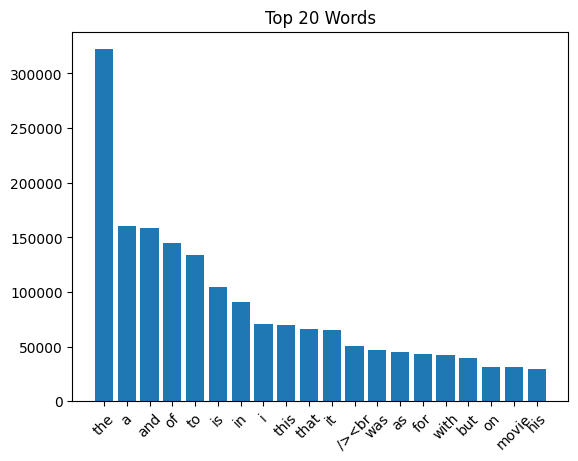

In [ ]:
from collections import Counter

all_words = " ".join(train['review'].astype(str)).lower().split()
common_words = Counter(all_words).most_common(20)

words_df = pd.DataFrame(common_words, columns=['word', 'count'])

plt.figure()
plt.bar(words_df['word'], words_df['count'])
plt.xticks(rotation=45)
plt.title("Top 20 Words")
plt.show()

**3.5 Word Cloud**

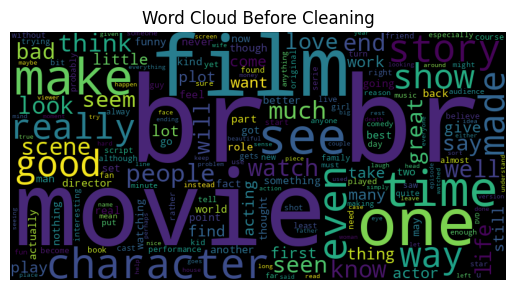

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400).generate(" ".join(train['review'].astype(str)))

plt.figure()
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud Before Cleaning")
plt.show()

**4. Pre-Processing**

In [ ]:
custom_stopwords = set(['would','could','also','one','get',])
all_stopwords = stop_words.union(custom_stopwords)

def handle_negation(text):
    text = re.sub(r"\bnot\s+(\w+)", r"not_\1", text)
    return text

def clean_text(text):
    # Ensure the input is a string before applying string methods
    text = str(text).lower()
    text = handle_negation(text)

    text = re.sub(r'[^ɐ-\uffff\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in all_stopwords and len(w) > 2
    ]

    return " ".join(words)

train['clean_text'] = train['review'].apply(clean_text)
test['clean_text'] = test['review'].apply(clean_text)

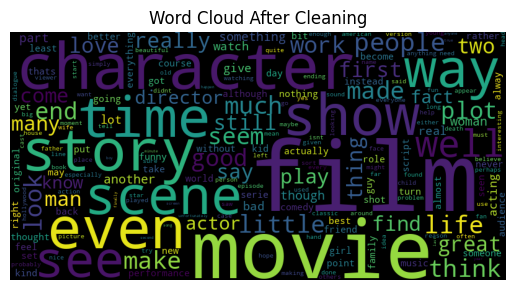

In [ ]:
plt.figure()
wordcloud = WordCloud(width=800, height=400).generate(" ".join(train['clean_text']))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud After Cleaning")
plt.show()

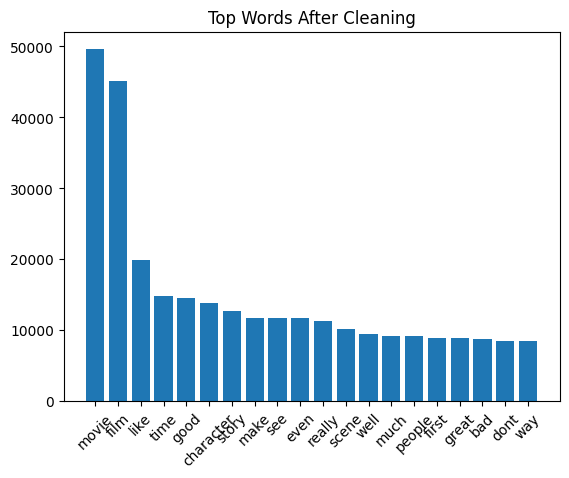

In [ ]:
common_words = Counter(" ".join(train['clean_text']).split()).most_common(20)

words_df = pd.DataFrame(common_words, columns=['word','count'])

plt.figure()
plt.bar(words_df['word'], words_df['count'])
plt.xticks(rotation=45)
plt.title("Top Words After Cleaning")
plt.show()

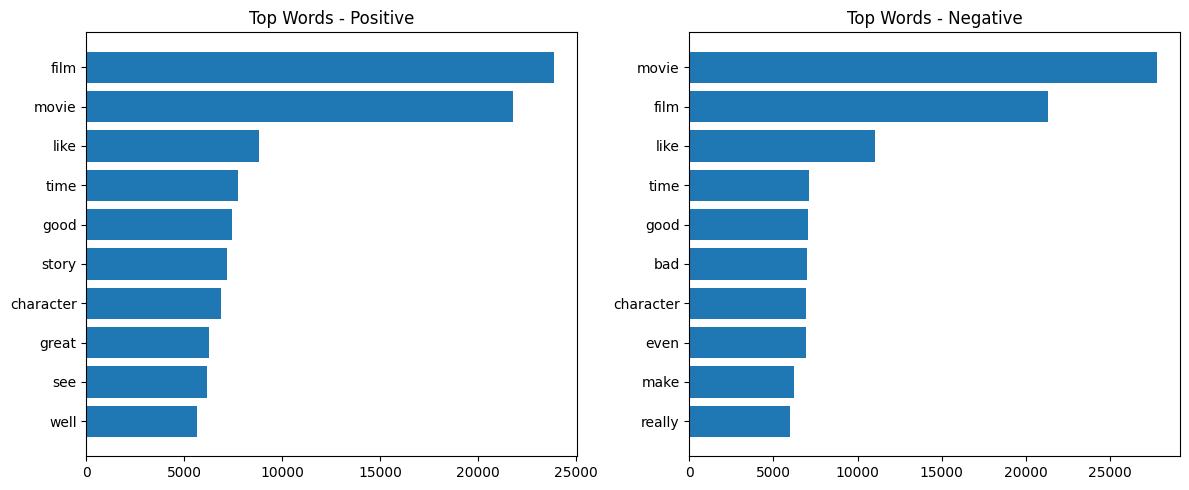

In [ ]:
from collections import Counter

# split by sentiment
positive_text = " ".join(train[train['sentiment'] == 1]['clean_text'])
negative_text = " ".join(train[train['sentiment'] == 0]['clean_text'])

# count words
pos_counts = Counter(positive_text.split()).most_common(10)
neg_counts = Counter(negative_text.split()).most_common(10)

# convert to dataframe
import pandas as pd
pos_df = pd.DataFrame(pos_counts, columns=['word','count'])
neg_df = pd.DataFrame(neg_counts, columns=['word','count'])


# Side by side plot
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Positive
axes[0].barh(pos_df['word'], pos_df['count'])
axes[0].set_title("Top Words - Positive")
axes[0].invert_yaxis()

# Negative
axes[1].barh(neg_df['word'], neg_df['count'])
axes[1].set_title("Top Words - Negative")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**5. Feature Engineering (TF-IDF + NGram)**

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8
)

X = vectorizer.fit_transform(train['clean_text'])
y = train['sentiment']

X_test = vectorizer.transform(test['clean_text'])
y_test = test['sentiment']

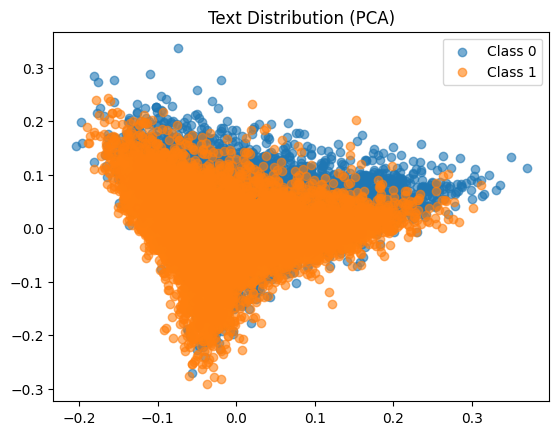

In [ ]:
from sklearn.decomposition import PCA

# reduce TF-IDF to 2D
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

plt.figure()

# color by label
for label in np.unique(y):
    plt.scatter(
        X_reduced[y == label, 0],
        X_reduced[y == label, 1],
        label=f"Class {label}",
        alpha=0.6
    )

plt.legend()
plt.title("Text Distribution (PCA)")
plt.show()

**6. Train Validation Split**

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**7. Model 1 - Logistic Regression**

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)
print("LR Accuracy:", accuracy_score(y_val, y_pred_lr))

print("\nLR Classification Report:\n")
print(classification_report(y_val, y_pred_lr))

print("LR Confusion Matrix:\n", confusion_matrix(y_val, y_pred_lr))

LR Accuracy: 0.8884

LR Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      2485
           1       0.88      0.90      0.89      2515

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000

LR Confusion Matrix:
 [[2171  314]
 [ 244 2271]]


**8. Model 2 - Naive Bayes**

In [ ]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_val)
print("NB Accuracy:", accuracy_score(y_val, y_pred_nb))

print("\nNB Classification Report:\n")
print(classification_report(y_val, y_pred_nb))

print("NB Confusion Matrix:\n", confusion_matrix(y_val, y_pred_nb))

NB Accuracy: 0.863

NB Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.86      0.86      2485
           1       0.86      0.87      0.86      2515

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000

NB Confusion Matrix:
 [[2130  355]
 [ 330 2185]]


**9. Model 3 - SVM**

In [ ]:
svm = LinearSVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_val)
print("SVM Accuracy:", accuracy_score(y_val, y_pred_svm))

print("\nSVM Classification Report:\n")
print(classification_report(y_val, y_pred_svm))

print("SVM Confusion Matrix:\n", confusion_matrix(y_val, y_pred_svm))

SVM Accuracy: 0.8844

SVM Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      2485
           1       0.88      0.89      0.89      2515

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000

SVM Confusion Matrix:
 [[2184  301]
 [ 277 2238]]


**10. Model Comparison**

In [ ]:
print("\nModel Comparison")
print("LR:", accuracy_score(y_val, y_pred_lr))
print("NB:", accuracy_score(y_val, y_pred_nb))
print("SVM:", accuracy_score(y_val, y_pred_svm))


Model Comparison
LR: 0.8884
NB: 0.863
SVM: 0.8844


In [ ]:
print("LR F1:", classification_report(y_val, y_pred_lr, output_dict=True)['weighted avg']['f1-score'])
print("NB F1:", classification_report(y_val, y_pred_nb, output_dict=True)['weighted avg']['f1-score'])
print("SVM F1:", classification_report(y_val, y_pred_svm, output_dict=True)['weighted avg']['f1-score'])

LR F1: 0.8883687394957982
NB F1: 0.8629924640881547
SVM F1: 0.8843940065969295


**11. Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000),
        {'C': [0.1, 1, 10]}
    ),
    "Naive Bayes": (
        MultinomialNB(),
        {'alpha': [0.1, 1, 10]}
    ),
    "SVM": (
        LinearSVC(),
        {'C': [0.1, 1, 10]}
    )
}

**12. Cross Validation**

In [ ]:
results = {}

for name, (model, params) in models.items():
    print(f"\n===== {name} =====")

    grid = GridSearchCV(model, params, cv=3)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    print("Best Params:", grid.best_params_)

    # Cross validation (fast)
    cv_scores = cross_val_score(best_model, X, y, cv=3)
    cv_f1 = cross_val_score(best_model, X, y, cv=3, scoring='f1_weighted')

    print("CV Accuracy:", cv_scores.mean())
    print("CV F1 Score:", cv_f1.mean())

    # Test score
    test_score = best_model.score(X_test, y_test)
    print("Test Accuracy:", test_score)

    results[name] = {
        "model": best_model,
        "test_score": test_score
    }


===== Logistic Regression =====
Best Params: {'C': 1}
CV Accuracy: 0.8595600939468344
CV F1 Score: 0.8595569839060723
Test Accuracy: 0.88064

===== Naive Bayes =====
Best Params: {'alpha': 1}
CV Accuracy: 0.8264801050405346
CV F1 Score: 0.8264371664457603
Test Accuracy: 0.854

===== SVM =====
Best Params: {'C': 0.1}
CV Accuracy: 0.8597601595448507
CV F1 Score: 0.8597565190712989
Test Accuracy: 0.88172


In [ ]:
best_model_name = max(results, key=lambda x: results[x]['test_score'])
best_model = results[best_model_name]['model']

print("\nBest Model:", best_model_name)


Best Model: SVM


**13. Final test Validation**


Final Accuracy: 0.88172

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.88     12500
           1       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000


Confusion Matrix:
 [[10947  1553]
 [ 1404 11096]]


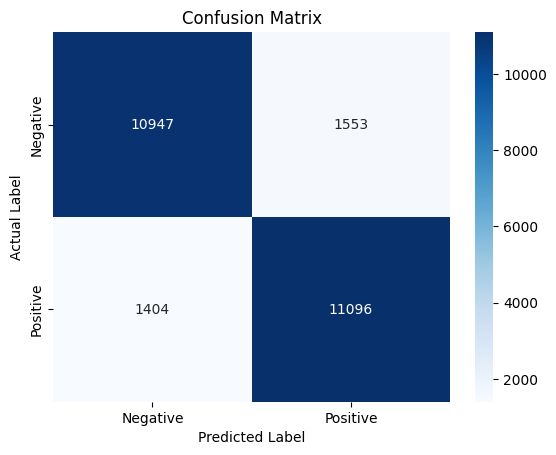

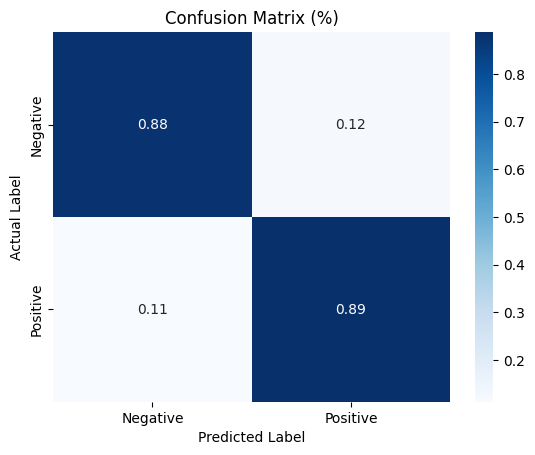

In [ ]:
final_pred = best_model.predict(X_test)

# Metrics
print("\nFinal Accuracy:", accuracy_score(y_test, final_pred))
print("\nClassification Report:\n", classification_report(y_test, final_pred))

cm = confusion_matrix(y_test, final_pred)
print("\nConfusion Matrix:\n", cm)

# Heatmap
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

# Percentage
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure()
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (%)")
plt.show()

**14. Error Analysis**

In [ ]:
test['predicted'] = final_pred

wrong = test[test['sentiment'] != test['predicted']]
print("\nWrong Predictions:")
print(wrong[['review', 'sentiment', 'predicted']].head(20))


Wrong Predictions:
                                                review  sentiment  predicted
14   My wife is a mental health therapist and we wa...          1          0
20   I have certainly not seen all of Jean Rollin's...          1          0
42   Naturally, along with everyone else, I was pri...          1          0
73   Madonna gets into action, again and she fails ...          1          0
81   So, Madonna isn't Meryl Streep. Still, this is...          1          0
90   Is this a bad movie?<br /><br />Of course, wha...          1          0
115  Two sisters, Su-mi (IM Soo-jung) and Su-yeon (...          1          0
118  This review is long overdue, since I consider ...          1          0
144  Despite some really scenic locations in the or...          1          0
166  I finally saw LAURE and I have to say that I e...          1          0
182  I put this second version of "The Man Who Knew...          1          0
188  Distributor: GOODTIMES home video <br /><br />...  

**15. Custom Prediction Function**

In [ ]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    return best_model.predict(vec)[0]

print("\nCustom Movie Review Sentiment Testing:\n")

print("\nPositive Reviews:\n")
print(predict_sentiment("This movie was absolutely amazing, the storyline was engaging and the acting was brilliant"))
print(predict_sentiment("I really loved this film, the cinematography was beautiful and the plot was very touching"))
print(predict_sentiment("One of the best movies I have ever watched, highly recommended to everyone"))

print("\nNegative Reviews:\n")
print(predict_sentiment("This movie was terrible, the plot made no sense and the acting was very poor"))
print(predict_sentiment("I regret watching this film, it was boring and a complete waste of time"))
print(predict_sentiment("The movie was disappointing, nothing interesting happened and it was too slow"))

print("\nNegation Reviews:\n")
print(predict_sentiment("This movie is not good at all, I did not enjoy it"))
print(predict_sentiment("The film is not bad, actually quite entertaining in some parts"))
print(predict_sentiment("I am not impressed with this movie, it could have been much better"))

print("\nMixed Reviews:\n")
print(predict_sentiment("The visuals were stunning but the story was very weak"))
print(predict_sentiment("Great acting but the plot was confusing and poorly executed"))
print(predict_sentiment("I liked some parts of the movie but overall it was disappointing"))

print("\nNeutral Reviews:\n")
print(predict_sentiment("The movie was okay, nothing special but not too bad either"))
print(predict_sentiment("It was an average film, some good scenes but also some boring moments"))


Custom Movie Review Sentiment Testing:


Positive Reviews:

1
1
1

Negative Reviews:

0
0
0

Negation Reviews:

0
1
0

Mixed Reviews:

0
0
0

Neutral Reviews:

0
0
